In [1]:
# Notebook 1 — NSL-KDD Core Training
# Run FIRST — produces gnn_model_*.pt for the eval notebooks.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from torch_geometric.nn import GCNConv, GATConv, SAGEConv, RGCNConv, GINConv, ChebConv
from torch_geometric.data import Data
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler


class GNNModel(torch.nn.Module):
    """
    6 GNN architectures in one class.
    self.model_type MUST be stored — forward() branches on it for RGCN.
    # MAINTENANCE: this class is duplicated in all 3 notebooks.
    # If you change it here, update 02_CICIDS_Evaluation_FINAL.ipynb
    # and 03_UNSW_Evaluation_FINAL.ipynb to match.
    """
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super().__init__()
        self.model_type = model_type

        if model_type == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
            self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, concat=False)
        elif model_type == 'SAGE':
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)
        elif model_type == 'RGCN':
            self.conv1 = RGCNConv(input_dim, hidden_dim, num_relations=1)
            self.conv2 = RGCNConv(hidden_dim, output_dim, num_relations=1)
        elif model_type == 'GIN':
            mlp1 = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                  nn.Linear(hidden_dim, hidden_dim))
            mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Linear(hidden_dim, output_dim))
            self.conv1 = GINConv(mlp1, train_eps=True)
            self.conv2 = GINConv(mlp2, train_eps=True)
        elif model_type == 'CHEB':
            self.conv1 = ChebConv(input_dim, hidden_dim, K=3)
            self.conv2 = ChebConv(hidden_dim, output_dim, K=3)
        else:
            raise ValueError(f'Unknown model_type: {model_type}')

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        if self.model_type == 'RGCN':
            et = torch.zeros(edge_index.size(1), dtype=torch.long)
            x = F.relu(self.conv1(x, edge_index, et))
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index, et)
        else:
            x = F.relu(self.conv1(x, edge_index))
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

@torch.no_grad()
def evaluate(model, data):
    """Notebook 1 only — scores held-out test_mask nodes."""
    model.eval()
    logits = model(data)
    preds  = logits[data.test_mask].argmax(dim=1)
    y_true = data.y[data.test_mask]
    probs  = logits[data.test_mask].exp()[:, 1]
    yt, yp, pr = y_true.cpu(), preds.cpu(), probs.cpu()
    return dict(accuracy=accuracy_score(yt,yp),
                f1=f1_score(yt,yp,zero_division=0),
                precision=precision_score(yt,yp,zero_division=0),
                recall=recall_score(yt,yp,zero_division=0),
                roc_auc=roc_auc_score(yt,pr))

def make_graph(X_vals, y_vals, split=True):
    """
    Build a bidirectional sequential graph.
    Bidirectional edges (i→i+1 AND i+1→i) give GCN a 2-node neighbourhood
    instead of 1-node, which is critical for GCN convergence on chain graphs.
    """
    N = len(y_vals)
    fwd = [np.arange(0, N-1), np.arange(1, N)]
    bwd = [np.arange(1, N),   np.arange(0, N-1)]   # reversed direction
    ei  = torch.tensor(np.concatenate([fwd, bwd], axis=1), dtype=torch.long)

    g = Data(x=torch.tensor(X_vals, dtype=torch.float),
             edge_index=ei,
             y=torch.tensor(y_vals, dtype=torch.long))
    if split:
        from sklearn.model_selection import train_test_split
        tr, te = train_test_split(np.arange(N), test_size=0.2,
                                  stratify=y_vals, random_state=42)
        tm = torch.zeros(N, dtype=torch.bool); tm[tr] = True
        vm = torch.zeros(N, dtype=torch.bool); vm[te] = True
        g.train_mask = tm; g.test_mask = vm
    return g
print("Setup complete.")


Setup complete.


In [ ]:
# Load NSL-KDD 
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'attack_type','difficulty_level'
]
df = pd.read_csv('KDDTrain+.txt', names=columns, header=None)
df = df.dropna(subset=['attack_type'])
df['label'] = (df['attack_type'] != 'normal').astype(int)
print(f"Rows: {len(df)} | Attack rate: {df['label'].mean():.2%}")
print(df['label'].value_counts().to_string())


Rows: 125973 | Attack rate: 46.54%
label
0    67343
1    58630


In [ ]:
COMMON_FEATURES = [
    'duration', # connection duration
    'src_bytes', # bytes source→dest
    'dst_bytes', # bytes dest→source
    'count', # same-host connections in window
    'srv_count', # same-service connections in window
    'serror_rate', # SYN-error rate  (0-1)
    'rerror_rate', # REJ-error rate  (0-1)
    'same_srv_rate', # same-service rate (0-1)
]
X = df[COMMON_FEATURES].fillna(0).replace([np.inf,-np.inf], 0).values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'ids_scaler.pkl')
print(f"Shape: {X_scaled.shape}  NaN: {np.isnan(X_scaled).sum()}")
print("Scaler saved → ids_scaler.pkl")


Shape: (125973, 8)  NaN: 0
Scaler saved → ids_scaler.pkl


In [5]:
from sklearn.model_selection import train_test_split
data = make_graph(X_scaled, y, split=True)
print(f"Nodes: {data.num_nodes}  Edges: {data.num_edges}")
print(f"Train: {data.train_mask.sum().item()}  Test: {data.test_mask.sum().item()}")
print(f"Edges per node (avg): {data.num_edges/data.num_nodes:.1f}  ← should be ~2 for bidirectional chain")


Nodes: 125973  Edges: 251944
Train: 100778  Test: 25195
Edges per node (avg): 2.0  ← should be ~2 for bidirectional chain


In [ ]:
# Training 
model_types = ['GCN', 'GAT', 'SAGE', 'RGCN', 'GIN', 'CHEB']
comparison_results = {}

input_dim, hidden_dim, output_dim = X_scaled.shape[1], 64, 2

train_labels = y[data.train_mask.numpy()]
n0, n1 = (train_labels==0).sum(), (train_labels==1).sum()
w0, w1 = (n0+n1)/(2*n0), (n0+n1)/(2*n1)
cw = torch.tensor([w0, w1], dtype=torch.float)
print(f"Class weights → normal={w0:.3f}  attack={w1:.3f}\n")

for m_type in model_types:
    print(f"\nTraining {m_type} ...")
    model = GNNModel(input_dim, hidden_dim, output_dim, m_type)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-4)
    criterion = nn.CrossEntropyLoss(weight=cw)

    best_loss = float('inf')
    for epoch in range(1, 301):
        model.train()
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); optimizer.step()
        scheduler.step(loss.detach()) # .detach() silences the UserWarning
        if loss.item() < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), f'gnn_model_{m_type.lower()}.pt')
        if epoch % 60 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f} | LR: {lr:.5f}")

    model.load_state_dict(torch.load(f'gnn_model_{m_type.lower()}.pt', map_location='cpu', weights_only=True))
    r = evaluate(model, data)
    comparison_results[m_type] = r
    print(f"  Best loss: {best_loss:.4f} | Acc: {r['accuracy']:.4f} | F1: {r['f1']:.4f}")

print("\nAll 6 models trained and saved.")


Class weights → normal=0.935  attack=1.074

Training GCN ...
  Epoch  60 | Loss: 0.5142 | LR: 0.01000
  Epoch 120 | Loss: 0.5083 | LR: 0.01000
  Epoch 180 | Loss: 0.5058 | LR: 0.01000
  Epoch 240 | Loss: 0.5052 | LR: 0.00250
  Epoch 300 | Loss: 0.5048 | LR: 0.00125
  Best loss: 0.5042 | Acc: 0.7525 | F1: 0.7344
Training GAT ...
  Epoch  60 | Loss: 0.4701 | LR: 0.01000
  Epoch 120 | Loss: 0.4550 | LR: 0.01000
  Epoch 180 | Loss: 0.4239 | LR: 0.01000
  Epoch 240 | Loss: 0.3742 | LR: 0.01000
  Epoch 300 | Loss: 0.3629 | LR: 0.01000
  Best loss: 0.3623 | Acc: 0.8699 | F1: 0.8507
Training SAGE ...
  Epoch  60 | Loss: 0.2710 | LR: 0.01000
  Epoch 120 | Loss: 0.2632 | LR: 0.01000
  Epoch 180 | Loss: 0.2598 | LR: 0.01000
  Epoch 240 | Loss: 0.2583 | LR: 0.01000
  Epoch 300 | Loss: 0.2551 | LR: 0.01000
  Best loss: 0.2549 | Acc: 0.9002 | F1: 0.8817
Training RGCN ...
  Epoch  60 | Loss: 0.2725 | LR: 0.01000
  Epoch 120 | Loss: 0.2657 | LR: 0.01000
  Epoch 180 | Loss: 0.2634 | LR: 0.01000
  Epoch

NSL-KDD In-Distribution Test Results:
      accuracy      f1  precision  recall  roc_auc
GCN     0.7525  0.7344     0.7335  0.7353   0.8321
GAT     0.8699  0.8507     0.9132  0.7963   0.9061
SAGE    0.9002  0.8817     0.9837  0.7988   0.9380
RGCN    0.9001  0.8815     0.9835  0.7987   0.9367
GIN     0.8651  0.8490     0.8859  0.8150   0.9250
CHEB    0.8995  0.8809     0.9822  0.7986   0.9338


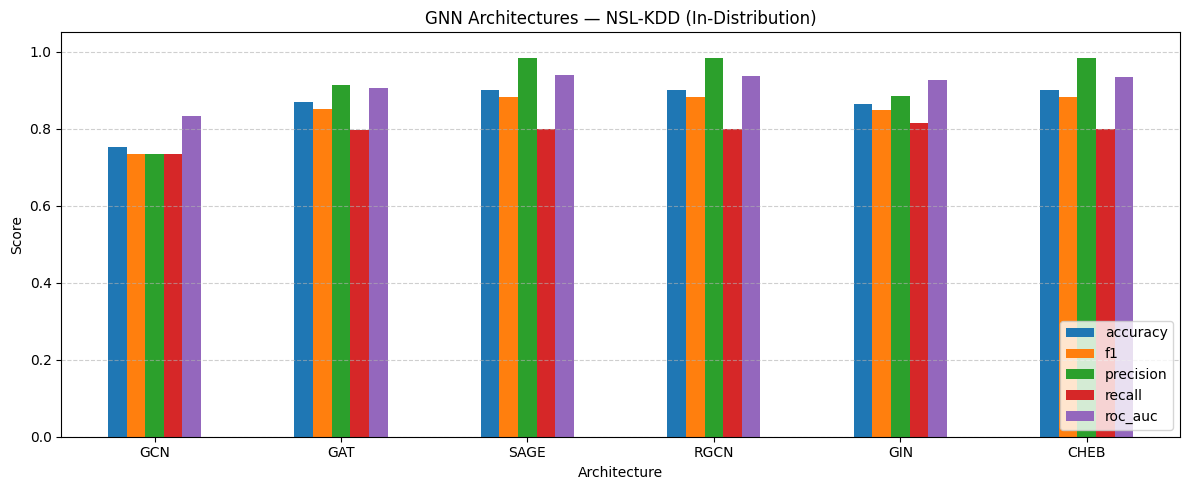

In [7]:
df_res = pd.DataFrame(comparison_results).T.round(4)
print("NSL-KDD In-Distribution Test Results:")
print(df_res.to_string())

fig, ax = plt.subplots(figsize=(12,5))
df_res.plot(kind='bar', ax=ax)
ax.set_title('GNN Architectures - NSL-KDD (In-Distribution)')
ax.set_ylabel('Score'); ax.set_xlabel('Architecture')
ax.set_ylim(0, 1.05); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right'); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()
